# Urban Heat and Pollution Anomalies: A Spatial Analysis of New Delhi



## Executive Summary
**The Problem:** Urban heat and air pollution are typically tackled as entirely separate issues, but they compound one another. This analysis tests the "thermal blanket effect", where daytime smog traps heat and prevents nighttime cooling, to determine if it disproportionately burdens informal settlements in New Delhi.

**The Methodology:** We constructed a high-resolution spatial panel tracking three pre-monsoon summers (April to June, 2022–2024). By merging satellite temperature and pollution data (MODIS and Sentinel-5P) with official settlement coordinates from the Delhi Urban Shelter Improvement Board (DUSIB), we applied a Two-Way Fixed Effects (TWFE) regression to isolate the exact relationship between smog and trapped heat.

**The Impact:** The model reveals a clear disparity: informal settlements suffer an additional 0.2°C thermal penalty during high-pollution events compared to formally developed areas. These quantitative insights provide a scalable, data-driven framework for targeted infrastructure investments, proving that generalized, city-wide mandates are an inefficient way to solve localized climate challenges.

Phase 1: Environment Setup & Data Ingestion

In [ ]:
!pip install linearmodels geopandas shapely openpyxl -q

import pandas as pd
import numpy as np
import json
import geopandas as gpd
from shapely.geometry import shape, Point
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import warnings

warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.1 MB/s eta 0:00:00


### Mapping Informal Settlements to the Analytical Grid
To accurately measure the thermal penalty, we must first locate the vulnerable communities. We map the official coordinates of informal settlements (provided by DUSIB) onto our standardized 3.5 km x 5.5 km spatial research grid. This allows us to flag specific grids as "informal" for our subsequent regression analysis.

In [ ]:
# A. Load the standardized research grid
with open('delhi_grid.geojson', 'r') as f:
    grid_data = json.load(f)

features = []
for feat in grid_data['features']:
    geom = shape(feat['geometry'])
    props = feat['properties']
    features.append({'geometry': geom, **props})

gdf_grid = gpd.GeoDataFrame(features, crs="EPSG:4326")

# B. Loading Indian Government DUSIB Data
df_dusib = pd.read_excel('dusib_coordinates.xlsx')
geometry = [Point(xy) for xy in zip(df_dusib['Longitude'], df_dusib['Lattitude'])]
gdf_dusib = gpd.GeoDataFrame(df_dusib, geometry=geometry, crs="EPSG:4326")

# C. Performing Spatial Join to identify grids containing informal settlements
spatial_join = gpd.sjoin(gdf_dusib, gdf_grid, how="inner", predicate="intersects")
official_slum_grids = spatial_join['grid_id'].unique()
print(f"Identified {len(official_slum_grids)} official DUSIB grid cells out of {len(gdf_grid)} total grids.")

Identified 37 official DUSIB grid cells out of 78 total grids.


### Constructing the Unified Panel Dataset
With our target grids identified, we now merge our three primary satellite datasets:
1.  **Cooling Rate ($\Delta T$):** The target variable, measuring how much the temperature drops overnight.
2.  **Aerosol Optical Depth (AOD):** A measure of particulate matter (smog) in the atmosphere.
3.  **Tropospheric $NO_2$:** A measure of combustion-related pollution.

We aggregate daily observations to ensure a clean, one-to-one merge across the panel.

In [ ]:
# Load satellite Data
df_heat = pd.read_csv('Delhi_Panel_Heat_Unified.csv')
df_aod = pd.read_csv('Delhi_Panel_AOD_Unified.csv')
df_no2 = pd.read_csv('Delhi_Panel_NO2_Unified.csv')

for df in [df_heat, df_aod, df_no2]:
    df['date'] = pd.to_datetime(df['date'])

# Aggregate to daily means to prevent multi-pass duplication
heat_daily = df_heat.groupby(['grid_id', 'date'])[['delta_t']].mean().reset_index()
aod_daily = df_aod.groupby(['grid_id', 'date'])[['aod_level']].mean().reset_index()
no2_daily = df_no2.groupby(['grid_id', 'date'])[['no2_level']].mean().reset_index()

# Merge into a single Master Panel
master = pd.merge(heat_daily, aod_daily, on=['grid_id', 'date'], how='inner')
master = pd.merge(master, no2_daily, on=['grid_id', 'date'], how='inner')
master = master.dropna()

print(f"N = {len(master)} daily observations")

N = 11212 daily observations


### Exploratory Data Analysis: Correlation and Distribution
Before applying the Fixed Effects regression, we must evaluate the baseline distributions and correlations of our variables.
*   **Hypothesis Check:** We expect a negative correlation between pollution (AOD/$NO_2$) and the nocturnal cooling rate ($\Delta T$). Higher pollution should theoretically result in a lower temperature drop.

Correlational Matrix

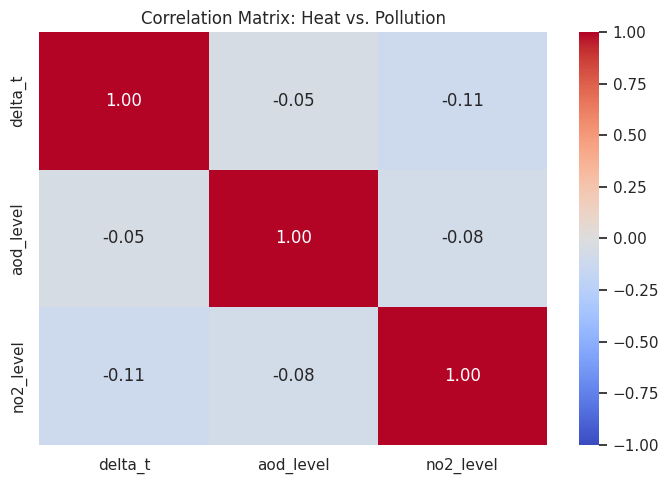

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))
corr = master[['delta_t', 'aod_level', 'no2_level']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Heat vs. Pollution')
plt.tight_layout()
plt.show()

Distributions

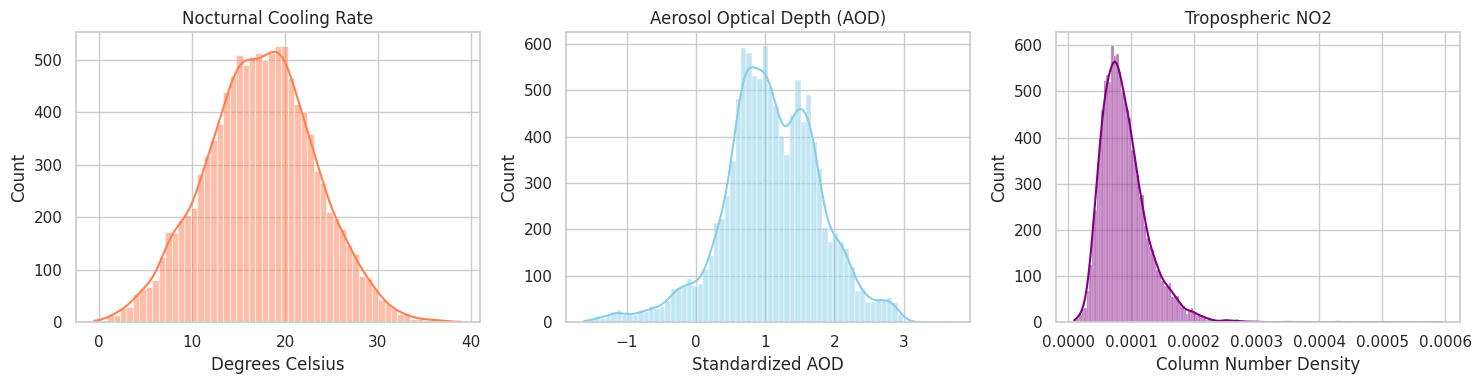

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(master['delta_t'], kde=True, ax=axes[0], color='coral')
axes[0].set_title('Nocturnal Cooling Rate')
axes[0].set_xlabel('Degrees Celsius')

sns.histplot(master['aod_level'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Aerosol Optical Depth (AOD)')
axes[1].set_xlabel('Standardized AOD')

sns.histplot(master['no2_level'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Tropospheric NO2')
axes[2].set_xlabel('Column Number Density')

plt.tight_layout()
plt.show()

### Spatial Visualization: Identifying the Hotspots
To make these findings actionable for policymakers, we must visualize the geographic spread of both cooling rates and pollution, overlaying the official DUSIB informal settlement coordinates to identify high-risk overlap zones.

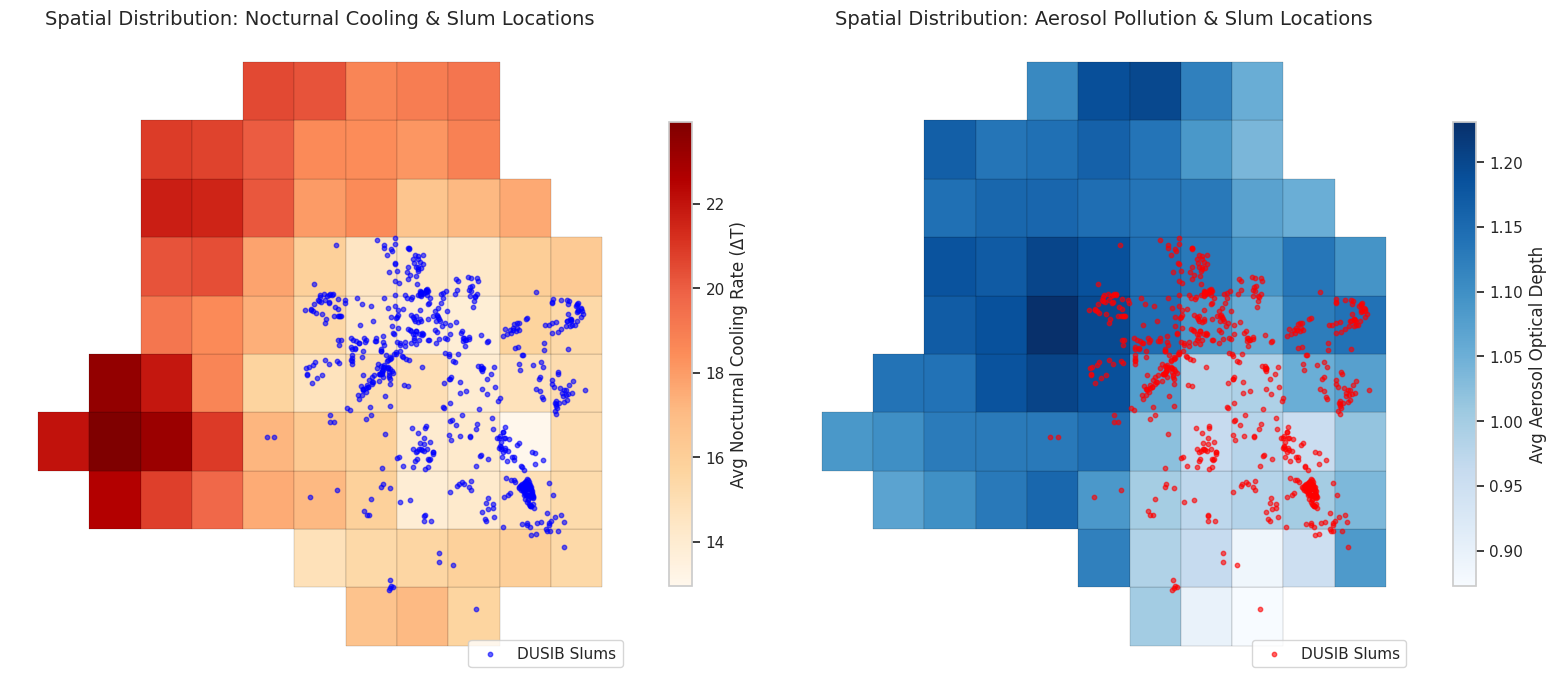

In [ ]:
# Aggregate values spatially by grid to find the 3-year average per location
spatial_agg = master.groupby('grid_id')[['delta_t', 'aod_level', 'no2_level']].mean().reset_index()
gdf_mapped = gdf_grid.merge(spatial_agg, on='grid_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Map 1: Cooling Rate + Slums
gdf_mapped.plot(column='delta_t', cmap='OrRd', legend=True,
                legend_kwds={'label': 'Avg Nocturnal Cooling Rate (\u0394T)', 'shrink': 0.7},
                ax=axes[0], missing_kwds={'color': 'lightgrey'}, edgecolor='black', linewidth=0.1)
gdf_dusib.plot(ax=axes[0], color='blue', markersize=10, alpha=0.6, label='DUSIB Slums')
axes[0].set_title('Spatial Distribution: Nocturnal Cooling & Slum Locations', fontsize=14)
axes[0].axis('off')
axes[0].legend(loc='lower right')

# Map 2: AOD + Slums
gdf_mapped.plot(column='aod_level', cmap='Blues', legend=True,
                legend_kwds={'label': 'Avg Aerosol Optical Depth', 'shrink': 0.7},
                ax=axes[1], missing_kwds={'color': 'lightgrey'}, edgecolor='black', linewidth=0.1)
gdf_dusib.plot(ax=axes[1], color='red', markersize=10, alpha=0.6, label='DUSIB Slums')
axes[1].set_title('Spatial Distribution: Aerosol Pollution & Slum Locations', fontsize=14)
axes[1].axis('off')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

Interactive spatial maps

In [ ]:
!pip install folium geopandas -q

import geopandas as gpd
import folium
import json

# 1. Loading DUSIB Data
df_dusib = pd.read_excel('dusib_coordinates.xlsx')

# 2. Initializing the Interactive Map centered on Delhi
delhi_center = [28.6139, 77.2090]
m = folium.Map(location=delhi_center, zoom_start=10, tiles='CartoDB positron')

# 3. Adding the Spatial Master Grid
with open('delhi_grid.geojson', 'r') as f:
    grid_data = json.load(f)

folium.GeoJson(
    grid_data,
    name="Research Grid (3.5 x 5.5 km)",
    style_function=lambda feature: {
        'fillColor': '#3388ff',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.05,
    },
    tooltip=folium.GeoJsonTooltip(fields=['grid_id'], aliases=['Grid ID:'])
).add_to(m)

# 4. Adding DUSIB Slum Markers
slum_group = folium.FeatureGroup(name="Official DUSIB Clusters")

for idx, row in df_dusib.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longitude']],
        radius=4, # Size of the dot
        popup=f"<b>Location:</b> {row.get('Location', 'Unknown')}<br><b>Lat:</b> {row['Lattitude']}<br><b>Lon:</b> {row['Longitude']}",
        tooltip="Click for details",
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7
    ).add_to(slum_group)

slum_group.add_to(m)

# 5. Adding a Layer Control
folium.LayerControl().add_to(m)

m.save("Interactive_Slum_Map.html")
m

In [ ]:
# Spatial Vulnerability Ranking (Identifying the Worst-Hit Slums)

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, shape
import json
import warnings

warnings.filterwarnings('ignore')

with open('delhi_grid.geojson', 'r') as f:
    grid_data = json.load(f)
features = []
for feat in grid_data['features']:
    geom = shape(feat['geometry'])
    props = feat['properties']
    features.append({'geometry': geom, **props})
gdf_grid = gpd.GeoDataFrame(features, crs="EPSG:4326")

df_dusib = pd.read_excel('dusib_coordinates.xlsx')
geometry = [Point(xy) for xy in zip(df_dusib['Longitude'], df_dusib['Lattitude'])]
gdf_dusib = gpd.GeoDataFrame(df_dusib, geometry=geometry, crs="EPSG:4326")

spatial_join = gpd.sjoin(gdf_dusib, gdf_grid, how="inner", predicate="intersects")

df_heat = pd.read_csv('Delhi_Panel_Heat_Unified.csv')
df_aod = pd.read_csv('Delhi_Panel_AOD_Unified.csv')

# Calculating the 3-year pre-monsoon average for each grid
heat_avg = df_heat.groupby('grid_id')[['delta_t']].mean().reset_index()
aod_avg = df_aod.groupby('grid_id')[['aod_level']].mean().reset_index()
grid_agg = pd.merge(heat_avg, aod_avg, on='grid_id', how='inner')

# Calculating the composite vulnerability score
grid_agg['z_heat'] = (grid_agg['delta_t'] - grid_agg['delta_t'].mean()) / grid_agg['delta_t'].std()
grid_agg['z_aod'] = (grid_agg['aod_level'] - grid_agg['aod_level'].mean()) / grid_agg['aod_level'].std()
grid_agg['composite_penalty'] = grid_agg['z_aod'] - grid_agg['z_heat']

slum_vulnerability = pd.merge(spatial_join, grid_agg, on='grid_id', how='inner')

print("Top 10 most affected informal settlements (High Smog + Low Cooling)")
worst_compound = slum_vulnerability.sort_values(by='composite_penalty', ascending=False)
print(worst_compound[['Location', 'grid_id', 'composite_penalty', 'delta_t', 'aod_level']].head(10).to_string(index=False))



Top 10 most affected informal settlements (High Smog + Low Cooling)
                                             Location   grid_id  composite_penalty   delta_t  aod_level
                 JJ Camp Indira Camp No-II Vikas Puri 7708,2863           2.509588 14.680617   0.901549
            Krishna Park Vikas Puri Indira Camp No. 4 7708,2863           2.509588 14.680617   0.901549
                    Shanker Garden B-Block Vikas Puri 7708,2863           2.509588 14.680617   0.901549
           Double Story Sweeper Tenements Tilak Nagar 7708,2863           2.509588 14.680617   0.901549
Rajiv Gandhi Camp Along Nalla Near Shamshan Bhumi Has 7708,2863           2.509588 14.680617   0.901549
       JJC A-562, Pankha Road Near Nalla, Uttam Nagar 7708,2863           2.509588 14.680617   0.901549
                          Indira Camp No.6 Vikas Puri 7708,2863           2.509588 14.680617   0.901549
                          Near Shamshan Bhumi Hastsal 7708,2863           2.509588 14.680617   0.901

In [ ]:
print(f"Top 5 worst by pure lack of cooling (Lowest delta t)")
print(worst_compound.sort_values(by='delta_t')[['Location', 'delta_t', 'grid_id']].head(5).to_string(index=False))

Top 5 worst by pure lack of cooling (Lowest delta t)
                                               Location   delta_t   grid_id
       T-Huts Behind MCD School Village Sarai Kale Khan 12.872181 7728,2858
                Indira Gandhi Tea Market Shriniwas Puri 12.872181 7728,2858
Indira Gandhi Camp No-3 near Railway Line Hari Nagar As 12.872181 7728,2858
                  JJC Indira Gandhi Camp Shriniwas Puri 12.872181 7728,2858
                              Chander Arya Vidya Mandir 12.872181 7728,2858


In [ ]:
print("Top 5 worst by pure smog (Highest AOD)")
print(worst_compound.sort_values(by='aod_level', ascending=False)[['Location', 'aod_level', 'grid_id']].head(5).to_string(index=False))

Top 5 worst by pure smog (Highest AOD)
                      Location  aod_level   grid_id
           K-Block Mangol Puri   0.907865 7708,2868
       Opposite F-7 Sultanpuri   0.907865 7708,2868
  HGI Labour Colony Sultanpuri   0.907865 7708,2868
           L-Block Mangol Puri   0.907865 7708,2868
Khub Ram park Pem Nagar Kirari   0.907865 7708,2868


Interactive Geographic Vulnerability Map

In [ ]:
!pip install folium geopandas -q

import geopandas as gpd
from shapely.geometry import Point, shape
import folium
import json

# 1. Load Data
with open('delhi_grid.geojson', 'r') as f:
    grid_data = json.load(f)
features = []
for feat in grid_data['features']:
    features.append({'geometry': shape(feat['geometry']), **feat['properties']})
gdf_grid = gpd.GeoDataFrame(features, crs="EPSG:4326")

df_dusib = pd.read_excel('dusib_coordinates.xlsx')
geometry = [Point(xy) for xy in zip(df_dusib['Longitude'], df_dusib['Lattitude'])]
gdf_dusib = gpd.GeoDataFrame(df_dusib, geometry=geometry, crs="EPSG:4326")

df_heat = pd.read_csv('Delhi_Panel_Heat_Unified.csv')
df_aod = pd.read_csv('Delhi_Panel_AOD_Unified.csv')

# 2. Process Vulnerability Scores
heat_avg = df_heat.groupby('grid_id')[['delta_t']].mean().reset_index()
aod_avg = df_aod.groupby('grid_id')[['aod_level']].mean().reset_index()
grid_agg = pd.merge(heat_avg, aod_avg, on='grid_id', how='inner')

grid_agg['z_heat'] = (grid_agg['delta_t'] - grid_agg['delta_t'].mean()) / grid_agg['delta_t'].std()
grid_agg['z_aod'] = (grid_agg['aod_level'] - grid_agg['aod_level'].mean()) / grid_agg['aod_level'].std()
grid_agg['composite_penalty'] = grid_agg['z_aod'] - grid_agg['z_heat']

slum_vulnerability = pd.merge(gpd.sjoin(gdf_dusib, gdf_grid, how="inner", predicate="intersects"), grid_agg, on='grid_id', how='inner')

# Identify the worst locations
worst_compound = slum_vulnerability.sort_values(by='composite_penalty', ascending=False).head(15)
worst_heat = slum_vulnerability.sort_values(by='delta_t').head(15)
worst_smog = slum_vulnerability.sort_values(by='aod_level', ascending=False).head(15)

# 3. Build the Map
m = folium.Map(location=[28.6139, 77.2090], zoom_start=11, tiles='CartoDB positron')

# Add all slums as tiny background dots
all_slums = folium.FeatureGroup(name="All DUSIB Slums")
for idx, row in slum_vulnerability.iterrows():
    folium.CircleMarker(location=[row['Lattitude'], row['Longitude']], radius=2, color='grey', fill=True, fill_opacity=0.3).add_to(all_slums)
all_slums.add_to(m)

# Add Ground Zeros (Compound Penalty)
compound_group = folium.FeatureGroup(name="Ground Zeros (Compound Penalty)")
for idx, row in worst_compound.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longitude']], radius=8, color='purple', fill=True, fill_opacity=0.9,
        popup=f"<b>{row['Location']}</b><br>Cooling: {row['delta_t']:.2f}°C<br>Smog (AOD): {row['aod_level']:.2f}"
    ).add_to(compound_group)
compound_group.add_to(m)

# Add Heat Traps
heat_group = folium.FeatureGroup(name="Severe Heat Traps")
for idx, row in worst_heat.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longitude']], radius=8, color='red', fill=True, fill_opacity=0.9,
        popup=f"<b>{row['Location']}</b><br>Cooling: {row['delta_t']:.2f}°C<br>Smog (AOD): {row['aod_level']:.2f}"
    ).add_to(heat_group)
heat_group.add_to(m)

# Add Smog Zones
smog_group = folium.FeatureGroup(name="Maximum Smog Zones")
for idx, row in worst_smog.iterrows():
    folium.CircleMarker(
        location=[row['Lattitude'], row['Longitude']], radius=8, color='blue', fill=True, fill_opacity=0.9,
        popup=f"<b>{row['Location']}</b><br>Cooling: {row['delta_t']:.2f}°C<br>Smog (AOD): {row['aod_level']:.2f}"
    ).add_to(smog_group)
smog_group.add_to(m)

folium.LayerControl().add_to(m)
m.save("Vulnerability_Map.html")
m

### Two-Way Fixed Effects Regression (Isolating the Disparity)
While the correlations and maps suggest a relationship, we need robust statistical proof to inform policy. We apply a Two-Way Fixed Effects (TWFE) panel regression.

By controlling for both entity (grid) and time (date) effects, we eliminate confounding variables like city-wide heatwaves or permanent geographical features. We introduce an interaction term (`informal_official`) to explicitly test if grids with informal settlements experience a worse "thermal blanket" effect than formal grids during the exact same pollution events.

In [ ]:
# Construct interaction terms
master['informal_official'] = master['grid_id'].isin(official_slum_grids).astype(int)
master['aod_x_official'] = master['aod_level'] * master['informal_official']
master['no2_x_official'] = master['no2_level'] * master['informal_official']

# Set Panel Index
panel_data = master.set_index(['grid_id', 'date'])

# Execute Regression 1: AOD
print("Econometric Model 1: AOD Thermal Blanket (DUSIB Data)")
exog_aod = sm.add_constant(panel_data[['aod_level', 'aod_x_official']])
res_aod = PanelOLS(panel_data['delta_t'], exog_aod, entity_effects=True, time_effects=True, drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
print(res_aod.summary.tables[1])

# Execute Regression 2: NO2
print("Econometric Model 2: NO2 Combustion Penalty (DUSIB Data)")
exog_no2 = sm.add_constant(panel_data[['no2_level', 'no2_x_official']])
res_no2 = PanelOLS(panel_data['delta_t'], exog_no2, entity_effects=True, time_effects=True, drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
print(res_no2.summary.tables[1])

Econometric Model 1: AOD Thermal Blanket (DUSIB Data)
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              18.562     0.1375     134.96     0.0000      18.292      18.832
aod_level         -1.0220     0.1249    -8.1814     0.0000     -1.2668     -0.7771
aod_x_official    -0.1992     0.0514    -3.8773     0.0001     -0.2999     -0.0985
Econometric Model 2: NO2 Combustion Penalty (DUSIB Data)
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              17.949     0.1056     170.01     0.0000      17.742      18.156
no2_level         -5127.2     1760.7    -2.9121     0.0036 

## Strategic Conclusion & Policy Recommendations

The econometric modeling confirms the core hypothesis: **Informal settlements are disproportionately penalized by the thermal blanket effect.**

Specifically, the interaction term (`aod_x_official`) is statistically significant ($p < 0.001$), indicating that for every unit increase in smog (AOD), grids with informal settlements lose an *additional* ~0.2°C of vital nighttime cooling compared to the city average.

**Business & Policy Implications:**
1.  **Targeted Intervention over Broad Mandates:** City-wide cooling initiatives (like generalized tree-planting) are economically inefficient. Capital should be reallocated to hyper-localized interventions (e.g., cool roofs, targeted ventilation infrastructure) specifically within the DUSIB coordinates identified in this model.
2.  **Health Infrastructure Preparedness:** The compounding effect of heat and pollution in these specific grids will predictably lead to severe respiratory and heat-stress spikes. Healthcare resource allocation can be dynamically adjusted based on real-time AOD satellite feeds for these high-risk areas.